In [52]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Benchmark + 9 ETF sectoriels US (tous dispo depuis 1998, zéro trou)
benchmark = "SPY"
sectors = ["XLK", "XLF", "XLV", "XLY", "XLP", "XLI", "XLE", "XLU", "XLB"]
tickers = [benchmark] + sectors

raw = yf.download(tickers, start="2010-01-01", auto_adjust=False)["Adj Close"]
raw = raw.ffill(limit=5).dropna()

print(raw.shape)
print(raw.index.min().date(), "->", raw.index.max().date())
print(raw.isna().sum().sum(), "NaN")
raw.tail(3)

[*********************100%***********************]  10 of 10 completed

(4211, 10)
2010-01-04 -> 2026-09-30
0 NaN


Ticker,SPY,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,
2026-09-28,765.609985,49.470001,62.099998,54.189999,168.779999,194.529999,82.279999,39.250000,171.259995,109.000000
2026-09-29,764.200012,49.099998,61.540001,54.009998,169.130005,194.500000,81.849998,39.709999,170.729996,109.150002
2026-09-30,762.630005,48.700001,61.500000,53.400002,166.979996,195.750000,80.599998,39.439999,168.419998,108.839996


In [53]:
# --- Strategy 1: 200-day trend-following on SPY ---
spy = raw["SPY"].copy()

# 200-day moving average
ma200 = spy.rolling(window=200).mean()

# Signal: 1 if price > MA200 (invested), 0 otherwise (cash)
# .shift(1) = decision made yesterday, applied today => no look-ahead
signal = (spy > ma200).astype(int).shift(1)

# SPY daily returns
spy_ret = spy.pct_change()

# Strategy return = signal * same-day return
strat_ret_gross = signal * spy_ret

print("Time invested:", f"{signal.mean():.0%} of the period")
print("Number of position changes:", int(signal.diff().abs().sum()))
strat_ret_gross.tail(3)

Time invested: 81% of the period
Number of position changes: 79


,SPY
Date,
2026-09-28,-0.007441
2026-09-29,-0.001842
2026-09-30,-0.002054


In [54]:
# --- Costs + comparison vs SPY (buy & hold) ---
cost_per_change = 0.0010  # 10 bps per position change (entry or exit)

# Cost applied each time the position flips
costs = signal.diff().abs() * cost_per_change
strat_ret_net = strat_ret_gross - costs

# Equity curves (start at 1)
eq_strat = (1 + strat_ret_net).cumprod()
eq_spy   = (1 + spy_ret).cumprod()

# --- Performance metrics ---
def perf(returns):
    returns = returns.dropna()
    ann_ret = (1 + returns).prod() ** (252 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    eq = (1 + returns).cumprod()
    max_dd = (eq / eq.cummax() - 1).min()
    return ann_ret, ann_vol, sharpe, max_dd

r1, v1, s1, d1 = perf(strat_ret_net)
rb, vb, sb, db = perf(spy_ret)

print("                 Strategy 1 (trend)   SPY (buy & hold)")
print(f"Annual return    {r1:>8.2%}            {rb:>8.2%}")
print(f"Annual vol       {v1:>8.2%}            {vb:>8.2%}")
print(f"Sharpe           {s1:>8.2f}            {sb:>8.2f}")
print(f"Max drawdown     {d1:>8.2%}            {db:>8.2%}")

                 Strategy 1 (trend)   SPY (buy & hold)
Annual return       9.71%              14.09%
Annual vol         11.46%              17.05%
Sharpe               0.85                0.83
Max drawdown      -21.55%             -33.72%


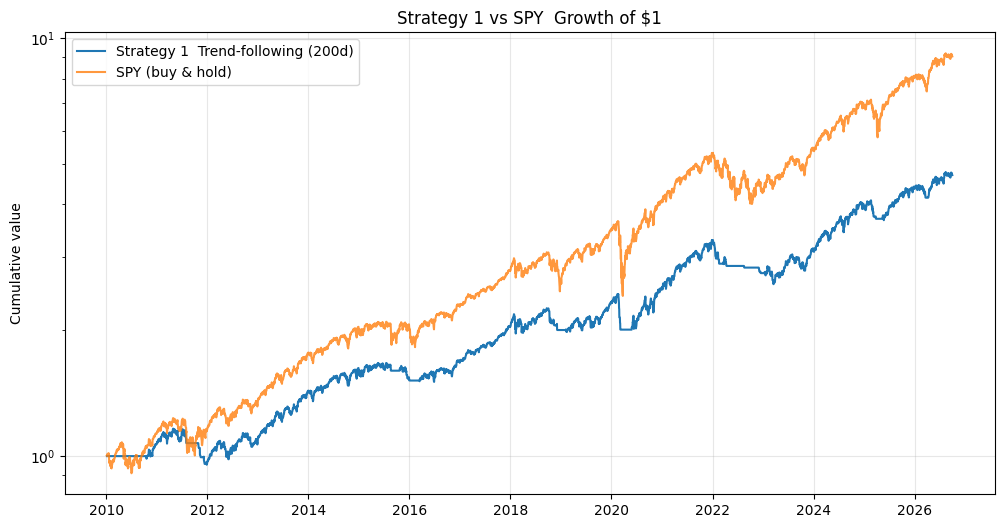

In [55]:
# --- Equity curve: Strategy 1 vs SPY ---
plt.figure(figsize=(12, 6))
plt.plot(eq_strat, label="Strategy 1  Trend-following (200d)", linewidth=1.5)
plt.plot(eq_spy, label="SPY (buy & hold)", linewidth=1.5, alpha=0.8)
plt.title("Strategy 1 vs SPY  Growth of $1")
plt.ylabel("Cumulative value")
plt.legend()
plt.grid(alpha=0.3)
plt.yscale("log")  # log scale: % moves are comparable over 17 years
plt.savefig("strategy1_equity.png", dpi=120, bbox_inches="tight")
plt.show()

In [56]:
# --- Strategy 2: Sector momentum rotation ---
prices = raw[sectors].copy()   # 9 sector ETFs (SPY excluded)

# 12-1 momentum: last 12 months return, skipping the most recent month
# (standard momentum definition, avoids short-term reversal noise)
momentum = prices.shift(21) / prices.shift(252) - 1

# Rank sectors each day, keep the top 3 (equal weight)
TOP_N = 3
ranks = momentum.rank(axis=1, ascending=False)
weights = (ranks <= TOP_N).astype(float)
weights = weights.div(weights.sum(axis=1), axis=0)   # equal weight, sums to 1

# Rebalance monthly: hold weights steady within the month
weights_monthly = weights.resample("ME").first().reindex(prices.index).ffill()

print("First valid date:", momentum.dropna().index.min().date())
print("Avg number of positions:", f"{(weights_monthly > 0).sum(axis=1).mean():.1f}")
weights_monthly.tail(3)

First valid date: 2011-01-03
Avg number of positions: 2.8


Ticker,XLK,XLF,XLV,XLY,XLP,XLI,XLE,XLU,XLB
Date,,,,,,,,,
2026-09-28,0.333333,0.0,0.333333,0.0,0.0,0.000000,0.333333,0.0,0.0
2026-09-29,0.333333,0.0,0.333333,0.0,0.0,0.000000,0.333333,0.0,0.0
2026-09-30,0.333333,0.0,0.000000,0.0,0.0,0.333333,0.333333,0.0,0.0


In [57]:
# --- Strategy 2 backtest: returns, costs, vs SPY ---
sector_ret = prices.pct_change()

# Portfolio return = yesterday's weights * today's returns (no look-ahead)
strat2_ret_gross = (weights_monthly.shift(1) * sector_ret).sum(axis=1)

# Turnover = how much the book changes at each rebalance
turnover = (weights_monthly - weights_monthly.shift(1)).abs().sum(axis=1)
strat2_costs = turnover * cost_per_change
strat2_ret_net = strat2_ret_gross - strat2_costs

# Align SPY on the same period (momentum needs 1 year of history)
start = momentum.dropna().index.min()
strat2_ret_net = strat2_ret_net.loc[start:]
spy_ret_aligned = spy_ret.loc[start:]

# Metrics (reusing perf() from cell 3)
r2, v2, s2, d2 = perf(strat2_ret_net)
rb2, vb2, sb2, db2 = perf(spy_ret_aligned)

print("Avg monthly turnover:", f"{turnover[turnover > 0].mean():.2f}")
print()
print("                 Strategy 2 (rotation)   SPY (buy & hold)")
print(f"Annual return    {r2:>8.2%}              {rb2:>8.2%}")
print(f"Annual vol       {v2:>8.2%}              {vb2:>8.2%}")
print(f"Sharpe           {s2:>8.2f}              {sb2:>8.2f}")
print(f"Max drawdown     {d2:>8.2%}              {db2:>8.2%}")

Avg monthly turnover: 0.81

                 Strategy 2 (rotation)   SPY (buy & hold)
Annual return      12.84%                14.14%
Annual vol         17.83%                17.00%
Sharpe               0.72                  0.83
Max drawdown      -38.71%               -33.72%


In [58]:
# --- Strategy 2 improved: dual momentum (relative + absolute filter) ---
# Keep top-3 sectors, but only those with positive absolute momentum.
# Non-qualifying slots go to cash (0% return, conservative).

in_top = momentum.rank(axis=1, ascending=False) <= TOP_N
positive = momentum > 0
hold = (in_top & positive).astype(float)

weights_dm = hold.div(TOP_N)   # fixed 1/3 per slot => cash when <3 qualify
weights_dm_monthly = weights_dm.resample("ME").first().reindex(prices.index).ffill()

# Backtest
strat2b_gross = (weights_dm_monthly.shift(1) * sector_ret).sum(axis=1)
turnover_dm = (weights_dm_monthly - weights_dm_monthly.shift(1)).abs().sum(axis=1)
strat2b_net = (strat2b_gross - turnover_dm * cost_per_change).loc[start:]

r2b, v2b, s2b, d2b = perf(strat2b_net)

print("            Rotation (plain)   Rotation + abs filter   SPY")
print(f"Ann return  {r2:>7.2%}           {r2b:>7.2%}              {rb2:>7.2%}")
print(f"Ann vol     {v2:>7.2%}           {v2b:>7.2%}              {vb2:>7.2%}")
print(f"Sharpe      {s2:>7.2f}           {s2b:>7.2f}              {sb2:>7.2f}")
print(f"Max DD      {d2:>7.2%}           {d2b:>7.2%}              {db2:>7.2%}")
print(f"% in cash   {(weights_dm_monthly.sum(axis=1) < 0.99).mean():>7.0%}")

            Rotation (plain)   Rotation + abs filter   SPY
Ann return   12.84%            12.60%               14.14%
Ann vol      17.83%            17.76%               17.00%
Sharpe         0.72              0.71                 0.83
Max DD      -38.71%           -38.71%              -33.72%
% in cash       10%


In [59]:
# --- Strategy 2 (final): sector rotation with a market trend overlay ---
# Hold top-3 sectors by momentum, but only when SPY is above its 200d MA.
# When SPY is below its MA200 (market downtrend), go fully to cash.

market_on = (spy > ma200).shift(1)   # daily trend filter, no look-ahead
market_on = market_on.reindex(prices.index).fillna(False)

# Base weights = plain top-3 rotation (equal weight)
weights_final = weights_monthly.copy()
# Kill all positions on days the market filter is off (=> cash)
weights_final = weights_final.mul(market_on.astype(float), axis=0)

# Backtest
strat2c_gross = (weights_final.shift(1) * sector_ret).sum(axis=1)
turnover_c = (weights_final - weights_final.shift(1)).abs().sum(axis=1)
strat2c_net = (strat2c_gross - turnover_c * cost_per_change).loc[start:]

r2c, v2c, s2c, d2c = perf(strat2c_net)

print("            Rotation plain   Rotation + trend overlay   SPY")
print(f"Ann return  {r2:>7.2%}          {r2c:>7.2%}                 {rb2:>7.2%}")
print(f"Ann vol     {v2:>7.2%}          {v2c:>7.2%}                 {vb2:>7.2%}")
print(f"Sharpe      {s2:>7.2f}          {s2c:>7.2f}                 {sb2:>7.2f}")
print(f"Max DD      {d2:>7.2%}          {d2c:>7.2%}                 {db2:>7.2%}")
print(f"% in cash   {(weights_final.sum(axis=1) < 0.99).mean():>7.0%}")

            Rotation plain   Rotation + trend overlay   SPY
Ann return   12.84%            8.45%                  14.14%
Ann vol      17.83%           12.61%                  17.00%
Sharpe         0.72             0.67                    0.83
Max DD      -38.71%          -20.63%                 -33.72%
% in cash       21%


/tmp/ipykernel_1494/936637196.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  market_on = market_on.reindex(prices.index).fillna(False)


In [60]:
# --- Combination: are the two strategies complementary? ---
# Align both net return streams on their common period
s1 = strat_ret_net.loc[start:]      # Strategy 1 (trend-following)
s2 = strat2_ret_net                 # Strategy 2 (plain rotation)

combo = 0.5 * s1 + 0.5 * s2         # naive 50/50 portfolio

print("Correlation between the two strategies:", f"{s1.corr(s2):.2f}")
print()
rc, vc, sc, dc = perf(combo)
print("            Strat 1   Strat 2   Combo 50/50   SPY")
print(f"Ann return  {perf(s1)[0]:>6.2%}   {perf(s2)[0]:>6.2%}    {rc:>6.2%}      {rb2:>6.2%}")
print(f"Ann vol     {perf(s1)[1]:>6.2%}   {perf(s2)[1]:>6.2%}    {vc:>6.2%}      {vb2:>6.2%}")
print(f"Sharpe      {perf(s1)[2]:>6.2f}   {perf(s2)[2]:>6.2f}    {sc:>6.2f}      {sb2:>6.2f}")
print(f"Max DD      {perf(s1)[3]:>6.2%}   {perf(s2)[3]:>6.2%}    {dc:>6.2%}      {db2:>6.2%}")

Correlation between the two strategies: 0.62

            Strat 1   Strat 2   Combo 50/50   SPY
Ann return   9.90%   12.84%    11.63%      14.14%
Ann vol     11.74%   17.83%    13.38%      17.00%
Sharpe        0.84     0.72      0.87        0.83
Max DD      -21.55%   -38.71%    -28.35%      -33.72%


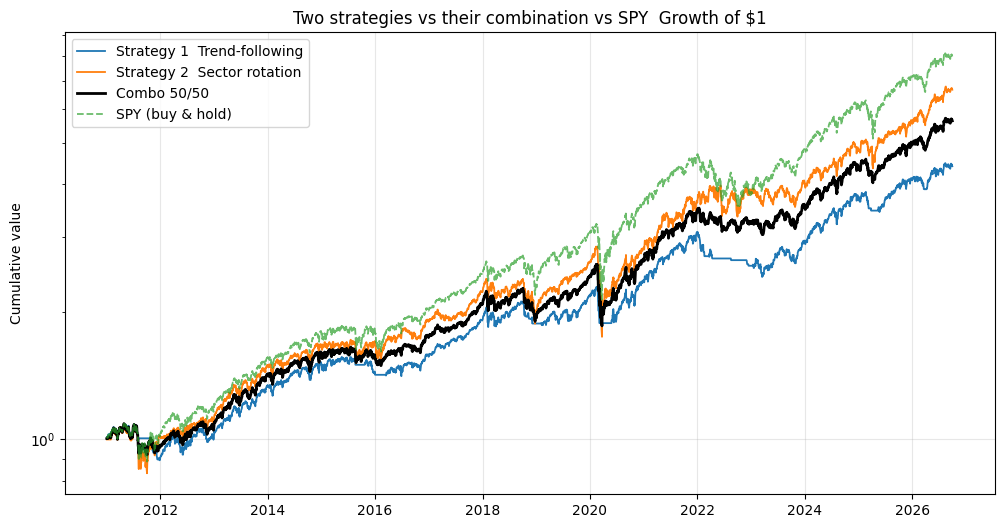

In [61]:
# --- Final chart: both strategies, the combo, and SPY ---
eq_s1    = (1 + s1).cumprod()
eq_s2    = (1 + s2).cumprod()
eq_combo = (1 + combo).cumprod()
eq_bench = (1 + spy_ret_aligned).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(eq_s1,    label="Strategy 1  Trend-following", linewidth=1.3)
plt.plot(eq_s2,    label="Strategy 2  Sector rotation", linewidth=1.3)
plt.plot(eq_combo, label="Combo 50/50", linewidth=2.0, color="black")
plt.plot(eq_bench, label="SPY (buy & hold)", linewidth=1.3, alpha=0.7, linestyle="--")
plt.title("Two strategies vs their combination vs SPY  Growth of $1")
plt.ylabel("Cumulative value")
plt.legend()
plt.grid(alpha=0.3)
plt.yscale("log")
plt.savefig("equity_curves.png", dpi=120, bbox_inches="tight")
plt.show()